## 1) Imports and Reproducible Setup

This cell imports the ODT generator, DLGN-SF model, and training utility from the package.
It also sets high-level experiment settings to match Paper 1's synthetic setup:
- depth = 4
- d = 100
- n = 40000
- beta = 10

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from first_experiment.odt import generate_cob_odt_data
from first_experiment.dlgn import DLGNSF
from first_experiment.training import TrainConfig, train_dlgn_sf, evaluate_dlgn_sf

# Paper-1-style synthetic setting
DIM = 100
DEPTH = 4
N_TRAIN = 40_000
SEED = 365

# DLGN-SF architecture from milestone plan
HIDDEN_DIMS = [20, 20, 20, 20]  # L=4, M=20
BETA = 30.0

## 2) Generate COB-ODT Data

This cell creates one synthetic dataset from a depth-4 COB-ODT with 30000 points.

In [47]:
x, y, tree, meta = generate_cob_odt_data(
    num_data=2*N_TRAIN,
    dim=DIM,
    depth=DEPTH,
    seed=SEED,
    threshold=0.0,
)

x_train = x[:N_TRAIN]
y_train = y[:N_TRAIN]
x_eval = x[N_TRAIN:]
y_eval = y[N_TRAIN:]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("meta:", meta)
print("label counts:", dict(zip(*np.unique(y_train, return_counts=True))))

x_train shape: (40000, 100)
y_train shape: (40000,)
meta: {'num_requested': 80000, 'num_kept': 80000, 'num_pruned': 0, 'dim': 100, 'depth': 4, 'num_internal_nodes': 15, 'num_leaf_nodes': 16, 'threshold': 0.0, 'seed': 365}
label counts: {np.int8(-1): np.int64(20132), np.int8(1): np.int64(19868)}


## 3) Build DLGN-SF and Capture Initial Gating Vectors

This cell initializes the model and extracts initial effective gating vectors V^l
(before training). These are the vectors we compare to ODT hyperplane normals.

In [48]:
model = DLGNSF(
    input_dim=DIM,
    hidden_dims=HIDDEN_DIMS,
    beta=BETA,
    bias=False,
    value_input_mode="ones",  # default in current code
)

init_gating = model.effective_gating_weights()  # list of tensors, one per hidden layer
print("num hidden layers:", len(init_gating))
print("layer shapes:", [tuple(w.shape) for w in init_gating])

num hidden layers: 4
layer shapes: [(20, 100), (20, 100), (20, 100), (20, 100)]


## 4) Train DLGN-SF on the Synthetic Data

This cell trains the model using Adam + BCE-with-logits via train_dlgn_sf.
You can increase epochs if needed for stronger clustering.

In [38]:
train_cfg = TrainConfig(
    epochs=5000,          # increase to 500+ if you want stronger effect
    lr=1e-4,
    batch_size=1024,
    seed=SEED,
    device="cpu",        # switch to "cuda" if available and desired
    snapshot_epochs=tuple(range(0, 5000, 200)),
    show_progress=True,
)

out = train_dlgn_sf(
    model=model,
    x_train=x_train,
    y_train=y_train,
    config=train_cfg,
)

final_model = out["model"]
epoch_losses = out["epoch_losses"]
final_gating = final_model.effective_gating_weights()

print("epochs logged:", len(epoch_losses))
print("initial loss:", epoch_losses[0], "final loss:", epoch_losses[-1])

Training DLGN-SF:   0%|          | 0/5001 [00:00<?, ?it/s]

epochs logged: 5000
initial loss: 0.6928221868515014 final loss: 3.582593546016142e-05


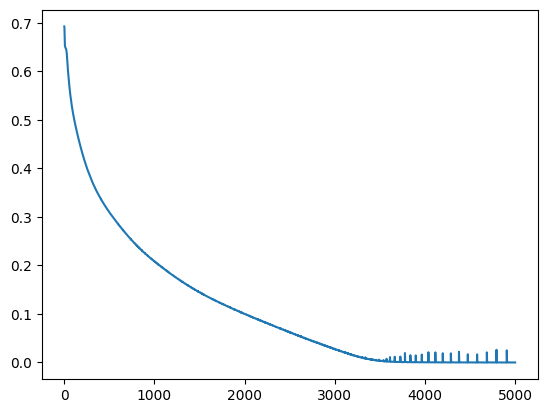

In [39]:
plt.plot(epoch_losses)

## 5) Helper Functions for Clustering Metrics

This cell defines small helpers:
- stack all gating vectors across layers,
- compute max cosine alignment to ODT normals,
- compute sign-invariant distance to hyperplane normals.

In [40]:
def stack_gating_vectors(gating_list):
    # gating_list: list of tensors, each shape (M, d)
    arrs = [w.detach().cpu().numpy() for w in gating_list]
    return np.concatenate(arrs, axis=0)  # shape: (L*M, d)

def max_abs_cosine_to_odt(gating_vectors, odt_normals):
    # returns vector of shape (num_gating_vectors,)
    g = gating_vectors / np.linalg.norm(gating_vectors, axis=1, keepdims=True)
    u = odt_normals / np.linalg.norm(odt_normals, axis=1, keepdims=True)
    cos_mat = np.abs(g @ u.T)  # sign-invariant
    return np.max(cos_mat, axis=1)

def min_sign_invariant_distance(gating_vectors, odt_normals):
    # distance between normalized vectors with sign invariance: min(||v-u||, ||v+u||)
    g = gating_vectors / np.linalg.norm(gating_vectors, axis=1, keepdims=True)
    u = odt_normals / np.linalg.norm(odt_normals, axis=1, keepdims=True)
    d1 = np.linalg.norm(g[:, None, :] - u[None, :, :], axis=2)
    d2 = np.linalg.norm(g[:, None, :] + u[None, :, :], axis=2)
    return np.min(np.minimum(d1, d2), axis=1)

# ODT internal-node normals
odt_normals = tree.w_list  # shape: (2^DEPTH - 1, DIM)

g_init = stack_gating_vectors(init_gating)
g_final = stack_gating_vectors(final_gating)

print("all gating vectors shape:", g_init.shape, "(expected L*M x d)")
print("ODT normals shape:", odt_normals.shape)

all gating vectors shape: (80, 100) (expected L*M x d)
ODT normals shape: (15, 100)


## 6) Quantitative Summary: Max Cosine and Min Distance

This cell computes and prints compact numeric summaries of clustering
before and after training.

In [41]:
cos_init = max_abs_cosine_to_odt(g_init, odt_normals)
cos_final = max_abs_cosine_to_odt(g_final, odt_normals)

dist_init = min_sign_invariant_distance(g_init, odt_normals)
dist_final = min_sign_invariant_distance(g_final, odt_normals)

summary = pd.DataFrame({
    "metric": ["max_abs_cosine", "min_sign_invariant_distance"],
    "init_mean": [cos_init.mean(), dist_init.mean()],
    "final_mean": [cos_final.mean(), dist_final.mean()],
    "init_median": [np.median(cos_init), np.median(dist_init)],
    "final_median": [np.median(cos_final), np.median(dist_final)],
})
summary

,metric,init_mean,final_mean,init_median,final_median
0,max_abs_cosine,0.207569,0.685340,0.202688,0.722606
1,min_sign_invariant_distance,1.258368,0.683413,1.262784,0.744795


## 7) Paper-1-Style Threshold Counts (Distance <= 0.1, 0.2, 0.3)

This cell reports how many gating vectors are close to *any* ODT hyperplane
under common distance thresholds, at init vs final.

In [42]:
thresholds = [0.1, 0.2, 0.3]
rows = []
for t in thresholds:
    rows.append({
        "threshold": t,
        "count_init": int(np.sum(dist_init <= t)),
        "count_final": int(np.sum(dist_final <= t)),
        "frac_init": float(np.mean(dist_init <= t)),
        "frac_final": float(np.mean(dist_final <= t)),
    })

pd.DataFrame(rows)

,threshold,count_init,count_final,frac_init,frac_final
0,0.1,0,10,0.0,0.125
1,0.2,0,16,0.0,0.200
2,0.3,0,20,0.0,0.250


## 8) Compute per-neuron alignment and nearest ODT hyperplane IDs

For each gating neuron vector v:
- norm(v)
- max_j |cos(v, u_j)|
- argmax_j |cos(v, u_j)|  (closest ODT hyperplane ID for coloring)

In [43]:

# Requires these to already exist from earlier cells:
# - tree (with tree.w_list)
# - init_gating (list of tensors from model init)
# - final_gating (list of tensors from trained model)

def stack_gating_vectors(gating_list):
    return np.concatenate([w.detach().cpu().numpy() for w in gating_list], axis=0)

def neuron_alignment_stats(gating_vectors, odt_normals):
    # Normalize rows
    g_norm = np.linalg.norm(gating_vectors, axis=1, keepdims=True)
    u_norm = np.linalg.norm(odt_normals, axis=1, keepdims=True)

    # Safety for near-zero rows (unlikely, but robust)
    g_norm = np.maximum(g_norm, 1e-12)
    u_norm = np.maximum(u_norm, 1e-12)

    g_unit = gating_vectors / g_norm
    u_unit = odt_normals / u_norm

    # Sign-invariant cosine similarity matrix: (num_neurons, num_odt_nodes)
    cos_abs = np.abs(g_unit @ u_unit.T)

    closest_id = np.argmax(cos_abs, axis=1)              # color label (0..num_odt-1)
    max_cos = cos_abs[np.arange(cos_abs.shape[0]), closest_id]
    norms = g_norm.squeeze(1)

    return norms, max_cos, closest_id

odt_normals = tree.w_list
g_init = stack_gating_vectors(init_gating)
g_final = stack_gating_vectors(final_gating)

norm_init, maxcos_init, closest_init = neuron_alignment_stats(g_init, odt_normals)
norm_final, maxcos_final, closest_final = neuron_alignment_stats(g_final, odt_normals)

print("Num neurons:", len(norm_init), "(should be L*M)")
print("Num ODT internal nodes:", odt_normals.shape[0])

Num neurons: 80 (should be L*M)
Num ODT internal nodes: 15


## 2) Scatter at initialization (one neuron = one point)

Color indicates nearest ODT hyperplane index.

/var/folders/pd/w8bnb5rs76g9lp6n7cpjt8ch0000gn/T/ipykernel_98882/3708832001.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_odt_nodes)


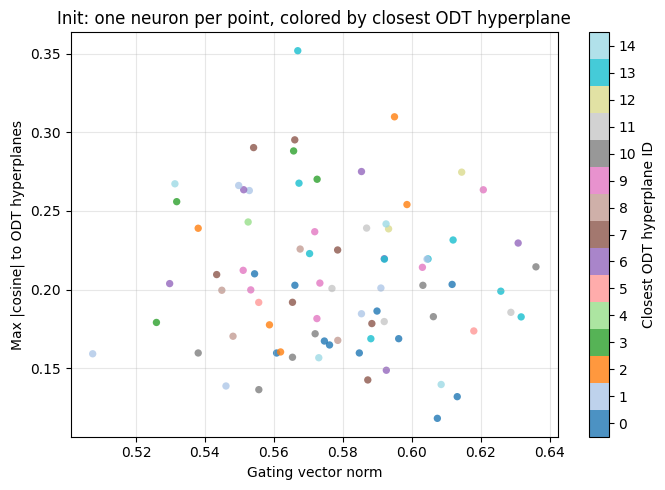

In [44]:
num_odt_nodes = odt_normals.shape[0]
cmap = plt.cm.get_cmap("tab20", num_odt_nodes)

plt.figure(figsize=(7, 5))
sc = plt.scatter(
    norm_init,
    maxcos_init,
    c=closest_init,
    cmap=cmap,
    s=28,
    alpha=0.8,
    edgecolors="none",
)

plt.xlabel("Gating vector norm")
plt.ylabel("Max |cosine| to ODT hyperplanes")
plt.title("Init: one neuron per point, colored by closest ODT hyperplane")
plt.grid(alpha=0.3)

# Discrete colorbar with integer IDs
cbar = plt.colorbar(sc, ticks=np.arange(num_odt_nodes))
cbar.set_label("Closest ODT hyperplane ID")
plt.clim(-0.5, num_odt_nodes - 0.5)

plt.tight_layout()
plt.show()

## 3) Scatter at final training epoch (one neuron = one point)

Same plot after training.

/var/folders/pd/w8bnb5rs76g9lp6n7cpjt8ch0000gn/T/ipykernel_98882/1424247287.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_odt_nodes)


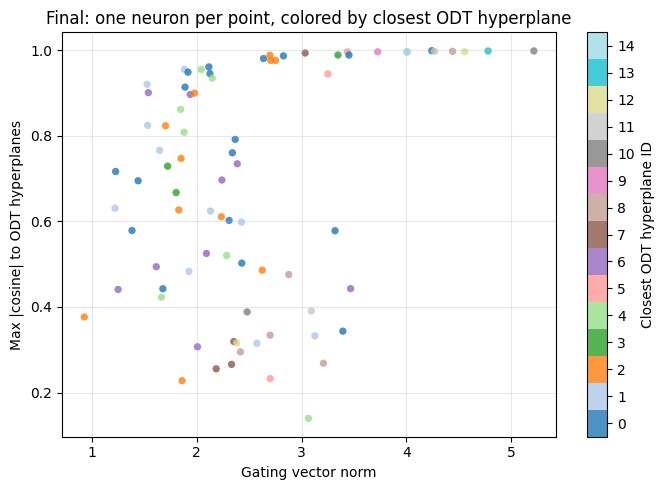

In [45]:
num_odt_nodes = odt_normals.shape[0]
cmap = plt.cm.get_cmap("tab20", num_odt_nodes)

plt.figure(figsize=(7, 5))
sc = plt.scatter(
    norm_final,
    maxcos_final,
    c=closest_final,
    cmap=cmap,
    s=28,
    alpha=0.8,
    edgecolors="none",
)

plt.xlabel("Gating vector norm")
plt.ylabel("Max |cosine| to ODT hyperplanes")
plt.title("Final: one neuron per point, colored by closest ODT hyperplane")
plt.grid(alpha=0.3)

cbar = plt.colorbar(sc, ticks=np.arange(num_odt_nodes))
cbar.set_label("Closest ODT hyperplane ID")
plt.clim(-0.5, num_odt_nodes - 0.5)

plt.tight_layout()
plt.show()

## 4) Optional side-by-side comparison (init vs final)

Same axes and color scheme for easier visual comparison.

/var/folders/pd/w8bnb5rs76g9lp6n7cpjt8ch0000gn/T/ipykernel_98882/3532095881.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_odt_nodes)


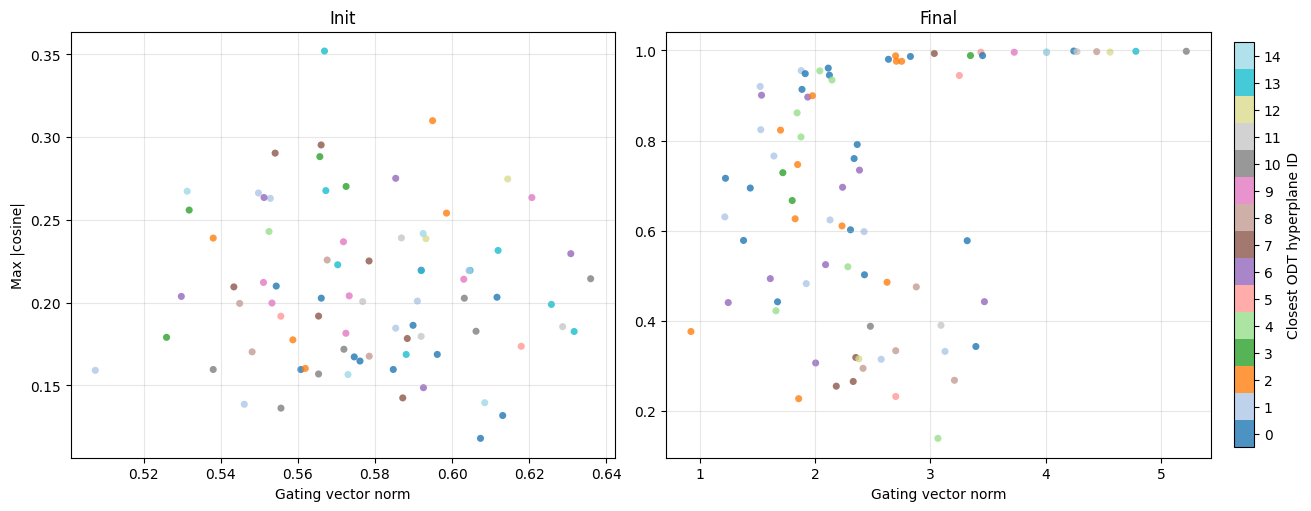

In [64]:
num_odt_nodes = odt_normals.shape[0]
cmap = plt.cm.get_cmap("tab20", num_odt_nodes)

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    constrained_layout=True,  
)

sc0 = axes[0].scatter(
    norm_init, maxcos_init, c=closest_init, cmap=cmap, s=26, alpha=0.8, edgecolors="none"
)
axes[0].set_title("Init")
axes[0].set_xlabel("Gating vector norm")
axes[0].set_ylabel("Max |cosine|")
axes[0].grid(alpha=0.3)

sc1 = axes[1].scatter(
    norm_final, maxcos_final, c=closest_final, cmap=cmap, s=26, alpha=0.8, edgecolors="none"
)
axes[1].set_title("Final")
axes[1].set_xlabel("Gating vector norm")
axes[1].grid(alpha=0.3)


cbar = fig.colorbar(
    sc1,
    ax=axes.ravel().tolist(),
    ticks=np.arange(num_odt_nodes),
    shrink=0.95,
    pad=0.02,
)
cbar.set_label("Closest ODT hyperplane ID")
sc1.set_clim(-0.5, num_odt_nodes - 0.5)

# Do NOT call plt.tight_layout() here
plt.show()

## Scatter at a chosen training epoch (from snapshots)

Set `EPOCH` to an integer that was included in `TrainConfig(snapshot_epochs=...)`.
If that epoch is missing from `out["snapshots"]`, re-run training with that epoch listed in `snapshot_epochs`.

In [ ]:

# ---- user argument ----
EPOCH = 100   # change this

# ---- expected variables from earlier cells ----
# out = train_dlgn_sf(...)
# tree = COB-ODT tree used for data
snapshots = out["snapshots"]
odt_normals = tree.w_list

if EPOCH not in snapshots:
    raise KeyError(
        f"No snapshot for epoch {EPOCH}. Available: {sorted(snapshots.keys())}"
    )

def stack_gating_numpy(gating_list):
    return np.concatenate([np.asarray(w) for w in gating_list], axis=0)

def neuron_alignment_stats(gating_vectors, odt_normals):
    g_norm = np.linalg.norm(gating_vectors, axis=1, keepdims=True)
    u_norm = np.linalg.norm(odt_normals, axis=1, keepdims=True)
    g_norm = np.maximum(g_norm, 1e-12)
    u_norm = np.maximum(u_norm, 1e-12)

    g_unit = gating_vectors / g_norm
    u_unit = odt_normals / u_norm

    cos_abs = np.abs(g_unit @ u_unit.T)
    closest_id = np.argmax(cos_abs, axis=1)
    max_cos = cos_abs[np.arange(cos_abs.shape[0]), closest_id]
    norms = g_norm.squeeze(1)
    return norms, max_cos, closest_id

g_epoch = stack_gating_numpy(snapshots[EPOCH])
norms, maxcos, closest = neuron_alignment_stats(g_epoch, odt_normals)

num_odt_nodes = odt_normals.shape[0]
cmap = plt.cm.get_cmap("tab20", num_odt_nodes)

plt.figure(figsize=(7, 5))
sc = plt.scatter(
    norms,
    maxcos,
    c=closest,
    cmap=cmap,
    s=28,
    alpha=0.8,
    edgecolors="none",
)

plt.xlabel("Gating vector norm")
plt.ylabel("Max |cosine| to ODT hyperplanes")
plt.title(f"Epoch {EPOCH}: one neuron per point, colored by closest ODT hyperplane")
plt.grid(alpha=0.3)

cbar = plt.colorbar(sc, ticks=np.arange(num_odt_nodes))
cbar.set_label("Closest ODT hyperplane ID")
plt.clim(-0.5, num_odt_nodes - 0.5)

plt.show()